Chapter 20. Portfolio Valuation



In [1]:
import sys
import os


target_path = os.path.abspath("../dx") #상위폴더의 dx폴더
sys.path.append(target_path)
import numpy as np

In [37]:
from pylab import mpl, plt

In [4]:
from dx_valuation import *

In [5]:
me_gbm = market_environment('me_gbm', dt.datetime(2020, 1, 1))  


In [6]:
me_gbm.add_constant('initial_value', 36.)  
me_gbm.add_constant('volatility', 0.2)  
me_gbm.add_constant('currency', 'EUR') 

In [7]:
me_gbm.add_constant('model', 'gbm')

In [8]:
from derivatives_position import derivatives_position

In [9]:
me_am_put = market_environment('me_am_put', dt.datetime(2020, 1, 1)) 

In [10]:
me_am_put.add_constant('maturity', dt.datetime(2020, 12, 31))  
me_am_put.add_constant('strike', 40.)  
me_am_put.add_constant('currency', 'EUR')  

In [11]:
payoff_func = 'np.maximum(strike - instrument_values, 0)' 

In [12]:
am_put_pos = derivatives_position(
name='am_put_pos',
quantity=3,
underlying='gbm',
mar_env=me_am_put,
otype='American',
payoff_func=payoff_func) 

In [13]:
am_put_pos.get_info()

NAME
am_put_pos 

QUANTITY
3 

UNDERLYING
gbm 

MARKET ENVIRONMENT

**Constants**
maturity 2020-12-31 00:00:00
strike 40.0
currency EUR

**Lists**

**Curves**

OPTION TYPE
American 

PAYOFF FUNCTION
np.maximum(strike - instrument_values, 0)


In [14]:
me_jd = market_environment('me_jd', me_gbm.pricing_date)

In [15]:
me_jd.add_constant('lambda', 0.3) 
me_jd.add_constant('mu', -0.75)
me_jd.add_constant('delta', 0.1)
me_jd.add_environment(me_gbm) 

In [16]:
me_jd.add_constant('model', 'jd') 

In [17]:
me_eur_call = market_environment('me_eur_call', me_jd.pricing_date)

In [18]:
me_eur_call.add_constant('maturity', dt.datetime(2020, 6, 30))
me_eur_call.add_constant('strike', 38.)
me_eur_call.add_constant('currency', 'EUR')

In [19]:
payoff_func = 'np.maximum(maturity_value - strike, 0)'

In [20]:
eur_call_pos = derivatives_position(
name='eur_call_pos',
quantity=5,
underlying='jd',
mar_env=me_eur_call,
otype='European',
payoff_func=payoff_func)

In [21]:
underlyings = {'gbm': me_gbm, 'jd' : me_jd}  
positions = {'am_put_pos' : am_put_pos,
'eur_call_pos' : eur_call_pos} 

In [22]:
csr = constant_short_rate('csr', 0.06)

In [23]:
val_env = market_environment('general', me_gbm.pricing_date)
val_env.add_constant('frequency', 'W')
val_env.add_constant('paths', 25000)
val_env.add_constant('starting_date', val_env.pricing_date)
val_env.add_constant('final_date', val_env.pricing_date)  
val_env.add_curve('discount_curve', csr)  

In [24]:
from derivatives_portfolio import derivatives_portfolio

In [25]:
portfolio = derivatives_portfolio(
name='portfolio',
positions=positions,
val_env=val_env,
assets=underlyings,
fixed_seed=False) 

In [26]:
%time portfolio.get_statistics(fixed_seed=False)

CPU times: total: 1.28 s
Wall time: 1.33 s


,name,quant.,value,curr.,pos_value,pos_delta,pos_vega
0,am_put_pos,3,4.633012,EUR,13.899036,-1.9884,42.3357
1,eur_call_pos,5,2.914060,EUR,14.570300,3.3510,43.5420


In [27]:
portfolio.get_statistics(fixed_seed=False)[['pos_value', 'pos_delta', 'pos_vega']].sum() 

pos_value    28.483829
pos_delta     1.342500
pos_vega     85.877700
dtype: float64

In [28]:
portfolio.get_positions() 


--------------------------------------------------
NAME
am_put_pos 

QUANTITY
3 

UNDERLYING
gbm 

MARKET ENVIRONMENT

**Constants**
maturity 2020-12-31 00:00:00
strike 40.0
currency EUR
frequency W
paths 25000
starting_date 2020-01-01 00:00:00
final_date 2020-12-31 00:00:00

**Lists**
time_grid [datetime.datetime(2020, 1, 1, 0, 0) datetime.datetime(2020, 1, 5, 0, 0)
 datetime.datetime(2020, 1, 12, 0, 0) datetime.datetime(2020, 1, 19, 0, 0)
 datetime.datetime(2020, 1, 26, 0, 0) datetime.datetime(2020, 2, 2, 0, 0)
 datetime.datetime(2020, 2, 9, 0, 0) datetime.datetime(2020, 2, 16, 0, 0)
 datetime.datetime(2020, 2, 23, 0, 0) datetime.datetime(2020, 3, 1, 0, 0)
 datetime.datetime(2020, 3, 8, 0, 0) datetime.datetime(2020, 3, 15, 0, 0)
 datetime.datetime(2020, 3, 22, 0, 0) datetime.datetime(2020, 3, 29, 0, 0)
 datetime.datetime(2020, 4, 5, 0, 0) datetime.datetime(2020, 4, 12, 0, 0)
 datetime.datetime(2020, 4, 19, 0, 0) datetime.datetime(2020, 4, 26, 0, 0)
 datetime.datetime(2020, 5, 3, 0, 

In [29]:
portfolio.valuation_objects['am_put_pos'].present_value()

np.float64(4.637843)

In [30]:
portfolio.valuation_objects['eur_call_pos'].delta()

np.float64(0.6711)

In [31]:
path_no = 888
path_gbm = portfolio.underlying_objects[
'gbm'].get_instrument_values()[:, path_no]
path_jd = portfolio.underlying_objects[
'jd'].get_instrument_values()[:, path_no]

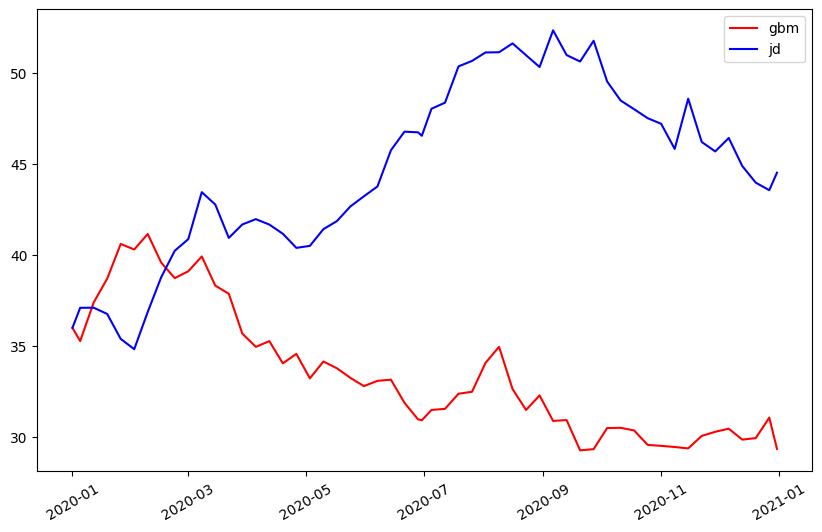

In [38]:
plt.figure(figsize=(10,6))
plt.plot(portfolio.time_grid, path_gbm, 'r', label='gbm')
plt.plot(portfolio.time_grid, path_jd, 'b', label='jd')
plt.xticks(rotation=30)
plt.legend(loc=0)

Figure 20-1. Noncorrelated risk factors (two sample paths)


In [39]:
correlations = [['gbm', 'jd', 0.9]]

In [40]:
port_corr = derivatives_portfolio(
name='portfolio',
positions=positions,
val_env=val_env,
assets=underlyings,
correlations=correlations,
fixed_seed=True)

In [41]:
port_corr.get_statistics()

,name,quant.,value,curr.,pos_value,pos_delta,pos_vega
0,am_put_pos,3,4.620772,EUR,13.862316,-1.9359,42.7728
1,eur_call_pos,5,2.902912,EUR,14.514560,3.4380,43.5095


In [43]:
path_gbm = port_corr.underlying_objects['gbm'].\
get_instrument_values()[:, path_no]
path_jd = port_corr.underlying_objects['jd'].\
    get_instrument_values()[:, path_no]

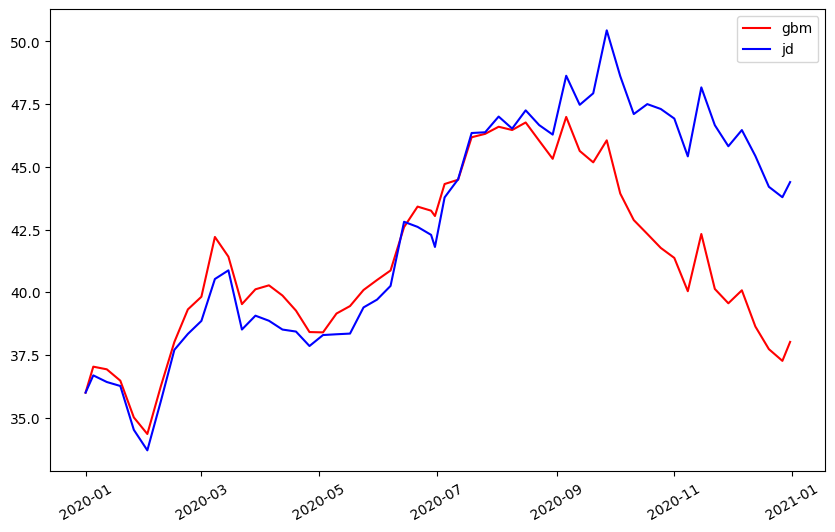

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(portfolio.time_grid, path_gbm, 'r', label='gbm')
plt.plot(portfolio.time_grid, path_jd, 'b', label='jd')
plt.xticks(rotation=30)
plt.legend(loc=0);

Figure 20-2. Correlated risk factors (two sample paths)

In [74]:
pv1 = 5 * port_corr.valuation_objects['eur_call_pos'].present_value(full=True)[1]
pv1

array([ 0.        , 40.91362618, 25.65941221, ...,  0.        ,
        6.62026499,  8.40476973], shape=(25000,))

In [77]:
pv2 = 3 * port_corr.valuation_objects['am_put_pos'].present_value(full=True)[1]
pv2

array([21.59315856, 11.9322554 , 19.97013408, ..., 21.71891723,
       12.80948124,  0.        ], shape=(25000,))

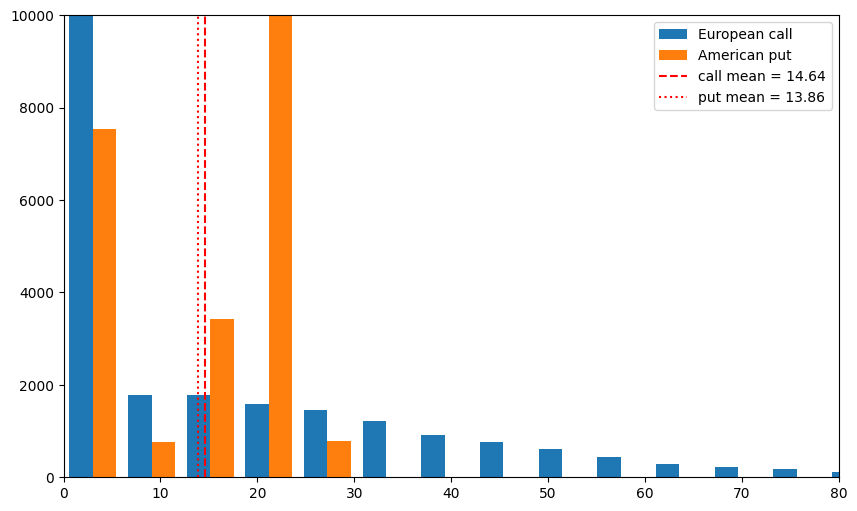

In [78]:
plt.figure(figsize=(10, 6))
plt.hist([pv1, pv2], bins=25,
label=['European call', 'American put']);
plt.axvline(pv1.mean(), color='r', ls='dashed',
lw=1.5, label='call mean = %4.2f' % pv1.mean())
plt.axvline(pv2.mean(), color='r', ls='dotted',
lw=1.5, label='put mean = %4.2f' % pv2.mean())
plt.xlim(0, 80); plt.ylim(0, 10000)
plt.legend();

Figure 20-3. Frequency distribution of present values of the two positions

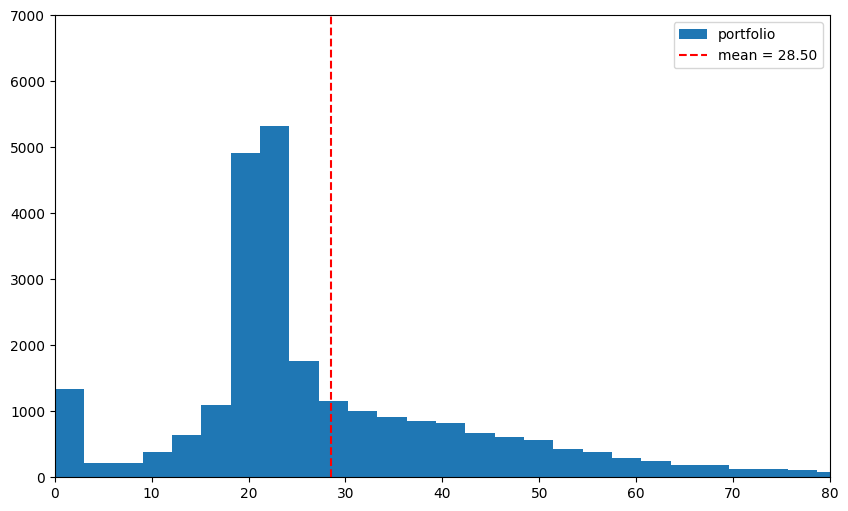

In [79]:
pvs = pv1 + pv2
plt.figure(figsize=(10, 6))
plt.hist(pvs, bins=50, label='portfolio');
plt.axvline(pvs.mean(), color='r', ls='dashed',
lw=1.5, label='mean = %4.2f' % pvs.mean())
plt.xlim(0, 80); plt.ylim(0, 7000)
plt.legend();

Figure 20-4. Portfolio frequency distribution of present values

In [60]:
pvs.std() 

np.float64(16.954571351675693)

In [61]:
pv1 = (5 * portfolio.valuation_objects['eur_call_pos'].
present_value(full=True)[1])
pv2 = (3 * portfolio.valuation_objects['am_put_pos'].
present_value(full=True)[1])
(pv1 + pv2).std()

np.float64(23.153712804216806)